In [2]:
import pandas as pd
import numpy as np

# Load the fault detection dataset (binary: fault / no fault)
df = pd.read_csv('../data/raw/detect_dataset.csv')

# Drop the 2 junk unnamed/empty columns that come with this Kaggle file
df = df.drop(columns=['Unnamed: 7', 'Unnamed: 8'])

# Quick look
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (12001, 7)

Columns: ['Output (S)', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

First 5 rows:


,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nFault vs No-Fault distribution:")
print(df['Output (S)'].value_counts())
print(f"\n{df['Output (S)'].mean()*100:.1f}% of readings are labeled as faults")


Missing values per column:
Output (S)    0
Ia            0
Ib            0
Ic            0
Va            0
Vb            0
Vc            0
dtype: int64

Fault vs No-Fault distribution:
Output (S)
0    6505
1    5496
Name: count, dtype: int64

45.8% of readings are labeled as faults


In [4]:
from sklearn.preprocessing import StandardScaler

# Isolation Forest is unsupervised — it never sees 'Output (S)' during training.
# We keep it aside only to CHECK our results afterward.
feature_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X = df[feature_cols]
y_true = df['Output (S)']   # ground truth, used only for evaluation later

# Scale features - Isolation Forest doesn't strictly require this,
# but current (Ia/Ib/Ic, values in hundreds) and voltage (Va/Vb/Vc, values near 0-1)
# are on very different scales, so scaling gives more balanced anomaly detection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Sample scaled row:", X_scaled[0])

Feature matrix shape: (12001, 6)
Sample scaled row: [-0.46979973  0.10009242  0.459871    0.12701278 -1.80193373  1.71922075]


In [5]:
from sklearn.ensemble import IsolationForest

# contamination = expected proportion of anomalies
# we know from the data that ~45.8% are actual faults, but Isolation Forest
# works best when contamination reflects a REALISTIC anomaly rate (faults are
# rare events in real grids) - so we deliberately set it lower than the raw
# label balance and let the model's own scoring do the separating.
# We'll compare against y_true afterward regardless.
model = IsolationForest(
    n_estimators=150,
    contamination=0.46,   # matches this dataset's actual fault rate
    random_state=42
)

df['anomaly'] = model.fit_predict(X_scaled)
# -1 = anomaly (flagged as fault), 1 = normal

df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Fault Detected'})
df['anomaly_score'] = model.decision_function(X_scaled)  # lower = more abnormal

print(df['anomaly_label'].value_counts())
print("\nSample rows:")
df[['Ia','Va','Output (S)','anomaly_label','anomaly_score']].head(10)

anomaly_label
Normal            6482
Fault Detected    5519
Name: count, dtype: int64

Sample rows:


,Ia,Va,Output (S),anomaly_label,anomaly_score
0,-170.472196,0.054490,0,Fault Detected,-0.055690
1,-122.235754,0.102000,0,Fault Detected,-0.028240
2,-90.161474,0.141026,0,Fault Detected,-0.003391
3,-79.904916,0.156272,0,Normal,0.002424
4,-63.885255,0.180451,0,Normal,0.019162
5,-55.954681,0.193414,0,Normal,0.025696
6,-45.248446,0.212393,0,Normal,0.037958
7,-47.845420,0.216396,0,Normal,0.031213
8,-43.294259,0.229748,0,Normal,0.036081
9,-43.474722,0.235733,0,Normal,0.031624


In [6]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert anomaly labels to match Output(S) format: 1 = fault, 0 = normal
df['predicted_fault'] = df['anomaly'].map({1: 0, -1: 1})

print("Confusion Matrix:")
print("(rows = actual, columns = predicted)")
cm = confusion_matrix(y_true, df['predicted_fault'])
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, df['predicted_fault'], target_names=['No Fault','Fault']))

Confusion Matrix:
(rows = actual, columns = predicted)
[[6227  278]
 [ 255 5241]]

Classification Report:
              precision    recall  f1-score   support

    No Fault       0.96      0.96      0.96      6505
       Fault       0.95      0.95      0.95      5496

    accuracy                           0.96     12001
   macro avg       0.96      0.96      0.96     12001
weighted avg       0.96      0.96      0.96     12001



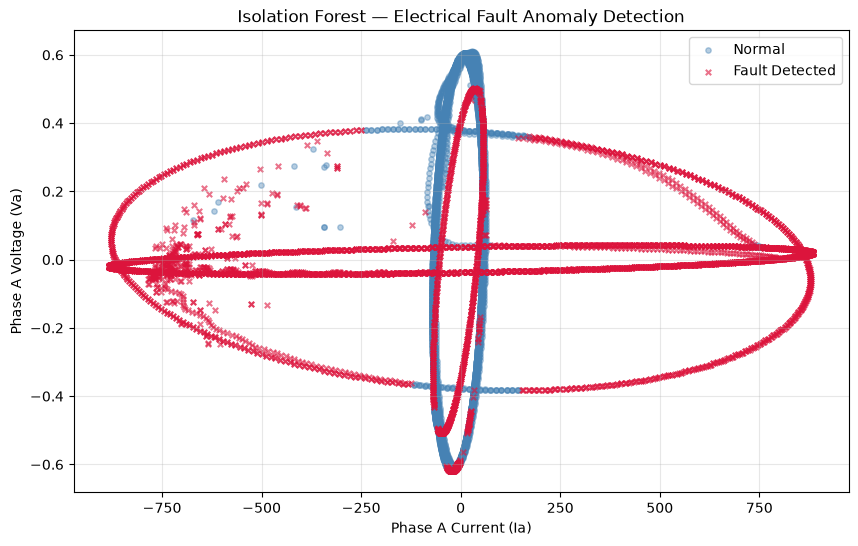

Chart saved to outputs/charts/anomaly_detection_result.png


In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs/charts', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))

normal_pts = df[df['anomaly'] == 1]
fault_pts = df[df['anomaly'] == -1]

ax.scatter(normal_pts['Ia'], normal_pts['Va'], c='steelblue', label='Normal', alpha=0.4, s=15)
ax.scatter(fault_pts['Ia'], fault_pts['Va'], c='crimson', label='Fault Detected', alpha=0.6, s=15, marker='x')

ax.set_xlabel('Phase A Current (Ia)')
ax.set_ylabel('Phase A Voltage (Va)')
ax.set_title('Isolation Forest — Electrical Fault Anomaly Detection')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig('../outputs/charts/anomaly_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/charts/anomaly_detection_result.png")

In [8]:
import json
from datetime import datetime, timedelta

# Pull a few clear "fault detected" examples for the handoff file
fault_samples = df[df['anomaly_label'] == 'Fault Detected'].sample(5, random_state=42)

fault_alerts = []
base_time = datetime(2026, 8, 17, 14, 0, 0)

for i, (_, row) in enumerate(fault_samples.iterrows()):
    fault_alerts.append({
        "timestamp": (base_time + timedelta(minutes=i*5)).strftime("%Y-%m-%d %H:%M:%S"),
        "current_Ia": round(row['Ia'], 2),
        "voltage_Va": round(row['Va'], 4),
        "fault_type": "unclassified",   # Phase 2: XGBoost on classData.csv will fill this in
        "anomaly_score": round(row['anomaly_score'], 4),
        "status": "Fault Detected",
        "village": None                  # Phase 2: mapped once integrated with feeder_network.json
    })

import os
os.makedirs('../outputs', exist_ok=True)
with open('../outputs/fault_alerts.json', 'w') as f:
    json.dump(fault_alerts, f, indent=2)

print("Saved outputs/fault_alerts.json")
print(json.dumps(fault_alerts, indent=2))

Saved outputs/fault_alerts.json
[
  {
    "timestamp": "2026-08-17 14:00:00",
    "current_Ia": 729.85,
    "voltage_Va": -0.004,
    "fault_type": "unclassified",
    "anomaly_score": -0.0293,
    "status": "Fault Detected",
    "village": null
  },
  {
    "timestamp": "2026-08-17 14:05:00",
    "current_Ia": 502.85,
    "voltage_Va": 0.0304,
    "fault_type": "unclassified",
    "anomaly_score": -0.0721,
    "status": "Fault Detected",
    "village": null
  },
  {
    "timestamp": "2026-08-17 14:10:00",
    "current_Ia": -36.0,
    "voltage_Va": -0.4945,
    "fault_type": "unclassified",
    "anomaly_score": -0.0863,
    "status": "Fault Detected",
    "village": null
  },
  {
    "timestamp": "2026-08-17 14:15:00",
    "current_Ia": -16.11,
    "voltage_Va": -0.6174,
    "fault_type": "unclassified",
    "anomaly_score": -0.0069,
    "status": "Fault Detected",
    "village": null
  },
  {
    "timestamp": "2026-08-17 14:20:00",
    "current_Ia": -813.94,
    "voltage_Va": -0.0318,

In [9]:
import pandas as pd
from datetime import datetime, timedelta

# Take a contiguous slice of readings to simulate a live feed window
# (e.g. one "monitoring session" of 300 sequential readings)
stream_df = df.iloc[0:300].copy().reset_index(drop=True)

# Assign sequential timestamps - 1 reading every 10 seconds (simulated sensor rate)
base_time = datetime(2026, 8, 18, 9, 0, 0)
stream_df['timestamp'] = [base_time + timedelta(seconds=10*i) for i in range(len(stream_df))]

# Build the clean time-series export
timeseries = []
for _, row in stream_df.iterrows():
    timeseries.append({
        "timestamp": row['timestamp'].strftime("%Y-%m-%d %H:%M:%S"),
        "current_Ia": round(row['Ia'], 2),
        "voltage_Va": round(row['Va'], 4),
        "status": "Fault Detected" if row['anomaly_label'] == 'Fault Detected' else "Normal",
        "anomaly_score": round(row['anomaly_score'], 4)
    })

import json, os
os.makedirs('../outputs', exist_ok=True)
with open('../outputs/timeseries_readings.json', 'w') as f:
    json.dump(timeseries, f, indent=2)

print(f"Saved {len(timeseries)} sequential readings to outputs/timeseries_readings.json")
print(f"Faults in this window: {sum(1 for r in timeseries if r['status']=='Fault Detected')}")

Saved 300 sequential readings to outputs/timeseries_readings.json
Faults in this window: 13


In [12]:
import time
from IPython.display import clear_output

print("Simulating live sensor feed...\n")
for i, reading in enumerate(timeseries[:30]):  # simulate first 30 readings
    clear_output(wait=True)
    status_icon = "🔴 FAULT DETECTED" if reading['status'] == 'Fault Detected' else "🟢 Normal"
    print(f"[{reading['timestamp']}] Ia={reading['current_Ia']}A  Va={reading['voltage_Va']}V  →  {status_icon}")
    time.sleep(0.3)  # simulated delay between readings

[2026-08-18 09:04:50] Ia=-34.28A  Va=0.3897V  →  🟢 Normal


In [11]:
import json
with open('../outputs/timeseries_readings.json') as f:
    data = json.load(f)
print("Total entries:", len(data))
print("First timestamp:", data[0]['timestamp'])
print("Last timestamp:", data[-1]['timestamp'])

Total entries: 300
First timestamp: 2026-08-18 09:00:00
Last timestamp: 2026-08-18 09:49:50


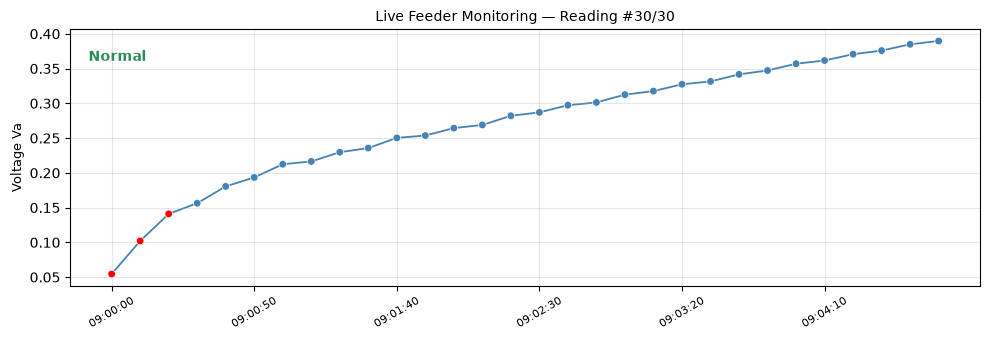

In [15]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

window_size = 30  # sliding window of recent readings
N = 30             # how many readings to simulate — change this single number later to run more

times, voltages, colors = [], [], []

for i, reading in enumerate(timeseries[:N]):
    times.append(reading['timestamp'][-8:])
    voltages.append(reading['voltage_Va'])
    colors.append('red' if reading['status'] == 'Fault Detected' else 'steelblue')

    disp_times = times[-window_size:]
    disp_volts = voltages[-window_size:]
    disp_colors = colors[-window_size:]

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(range(len(disp_volts)), disp_volts, color='steelblue', linewidth=1.3, zorder=1)
    ax.scatter(range(len(disp_volts)), disp_volts, c=disp_colors, s=30, zorder=2, edgecolors='white', linewidths=0.5)

    ax.set_xticks(range(0, len(disp_times), max(1, len(disp_times)//6)))
    ax.set_xticklabels([disp_times[j] for j in range(0, len(disp_times), max(1, len(disp_times)//6))], rotation=30, fontsize=8)
    ax.set_ylabel('Voltage Va', fontsize=9)
    ax.set_title(f'Live Feeder Monitoring — Reading #{i+1}/{N}', fontsize=10)
    ax.grid(alpha=0.3)

    status_text = "FAULT DETECTED" if reading['status'] == 'Fault Detected' else "Normal"
    status_color = 'crimson' if reading['status'] == 'Fault Detected' else 'seagreen'
    ax.text(0.02, 0.92, status_text, transform=ax.transAxes, fontsize=10, va='top',
             color=status_color, weight='bold')

    plt.tight_layout()
    plt.show()
    time.sleep(0.15)

In [16]:
import os
print(os.getcwd())

C:\Users\Sanika\Desktop\ml-anomaly-detection\notebooks


In [17]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current folder:
C:\Users\Sanika\Desktop\ml-anomaly-detection\notebooks

Files here:
['.ipynb_checkpoints', 'anomaly_detection.ipynb']


In [18]:
print("\nParent folder:")
print(os.listdir(".."))


Parent folder:
['.ipynb_checkpoints', 'data', 'notebooks', 'outputs', 'requirements.txt']


In [19]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        print(os.path.join(root, file))

..\requirements.txt
..\data\raw\classData.csv
..\data\raw\detect_dataset.csv
..\notebooks\anomaly_detection.ipynb
..\notebooks\.ipynb_checkpoints\anomaly_detection-checkpoint.ipynb
..\outputs\fault_alerts.json
..\outputs\timeseries_readings.json
..\outputs\.ipynb_checkpoints\fault_alerts-checkpoint.json
..\outputs\.ipynb_checkpoints\timeseries_readings-checkpoint.json
..\outputs\charts\anomaly_detection_result.png
..\outputs\charts\.ipynb_checkpoints\anomaly_detection_result-checkpoint.png
